In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
from transformers import RobertaTokenizer, RobertaModel
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from torch.utils.data import DataLoader, Subset
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.exceptions import FitFailedWarning
import warnings
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib
from sklearn.base import clone


In [2]:
import torch

# 检查是否有可用的 GPU
if torch.cuda.is_available():
    print("CUDA 可用，GPU 可用。")
    print(f"CUDA 版本: {torch.version.cuda}")
    print(f"GPU 数量: {torch.cuda.device_count()}")
    print(f"当前设备名称: {torch.cuda.get_device_name(0)}")
    print(f"当前设备总内存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("CUDA 不可用，仅支持 CPU。")


CUDA 可用，GPU 可用。
CUDA 版本: 12.4
GPU 数量: 1
当前设备名称: NVIDIA GeForce RTX 4090 D
当前设备总内存: 23.64 GB


In [6]:
# 数据增强函数：简单的 SMILES 序列翻转
def augment_smiles(smiles):
    """简单的数据增强方法，例如旋转 SMILES 字符串"""
    if random.random() > 0.5:
        return smiles[::-1]  # 翻转字符串
    return smiles

# 根据 mgperL 浓度生成分类标签
def generate_labels(mgperL):
    """根据 mgperL 的浓度范围生成分类标签"""
    if mgperL < 0.2:
        return 0  # high
    elif 0.2 <= mgperL < 1.5:
        return 1  # mid
    elif 1.5 <= mgperL < 3.5:
        return 2  # mid
    else:
        return 3  # low

# 数据集定义
class SMILES_Dataset(Dataset):
    def __init__(self, smiles, reg_labels, class_labels):
        self.smiles = smiles
        self.reg_labels = reg_labels  # 回归任务标签 (mgperL)
        self.class_labels = class_labels  # 分类任务标签

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        #smiles = augment_smiles(self.smiles[idx])  # 数据增强
        smiles = self.smiles[idx]  # 数据增强
        reg_label = self.reg_labels[idx]
        class_label = self.class_labels[idx]
        tokens = tokenizer(smiles, padding='max_length', truncation=True, max_length=128, return_tensors="pt")
        return tokens, torch.tensor(reg_label, dtype=torch.float32), torch.tensor(class_label, dtype=torch.long)

# 多任务模型定义
class ChemBERTa_MultiTask(nn.Module):
    def __init__(self, num_classes):
        super(ChemBERTa_MultiTask, self).__init__()
        # 加载预训练的ChemBERTa模型
        self.chemberta = chemberta_model
        hidden_size = self.chemberta.config.hidden_size  # 一般为768
        # 回归任务的全连接层
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

        # 分类任务的全连接层
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 4)
        )

    def forward(self, tokens):
        output = self.chemberta(**tokens)
        cls_embedding = output.last_hidden_state[:, 0, :]  # [CLS] token 嵌入
        reg_output = self.regressor(cls_embedding)  # 回归任务输出
        class_output = self.classifier(cls_embedding)  # 分类任务输出
        return reg_output, class_output

In [7]:
# 加载 ChemBERTa 模型和 tokenizer
model_name = "../ChemBERTa"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
chemberta_model = RobertaModel.from_pretrained(model_name)

In [8]:
data=pd.read_csv("./data/algae_EC10_train.csv")
data=data.dropna()
smiles_data = data['SMILES_Canonical_RDKit'].tolist()
mgperL = data['mgperL'].values
Duration_Value= data['Duration_Value'].values
mgperL=np.log1p(mgperL)

In [10]:
testdata = pd.read_excel('./algae_EC10_test.xlsx')

smiles_testdata = testdata['SMILES_Canonical_RDKit'].tolist()
y_test = testdata['mgperL'].values

y_test=np.log1p(y_test)

# # 提取嵌入
# smiles_embeddings_test = extract_embeddings(smiles_testdata, model, tokenizer, device)
# # 将需要的列拼接成输入 X
# x_test = np.hstack((smiles_embeddings_test, testdata['Duration_Value'].values.reshape(-1, 1)))




In [11]:
# 生成分类标签    
classification_labels = [generate_labels(mg) for mg in mgperL]

# 加载数据集



train_dataset = SMILES_Dataset(smiles_data, mgperL, classification_labels)

val_dataset = SMILES_Dataset(smiles_testdata, y_test, classification_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32,drop_last=True)

In [7]:
# # 生成分类标签    
# classification_labels = [generate_labels(mg) for mg in mgperL]

# # 加载数据集
# dataset = SMILES_Dataset(smiles_data, mgperL, classification_labels)

# train_size = int(0.8 * len(dataset))

# val_size = len(dataset) - train_size

# train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,drop_last=True)
# val_loader = DataLoader(val_dataset, batch_size=32,drop_last=True)

In [12]:
# 初始化多任务模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ChemBERTa_MultiTask(chemberta_model).to(device)

In [13]:


# 损失函数
reg_criterion = nn.L1Loss()  # 回归任务的损失
class_criterion = nn.CrossEntropyLoss()  # 分类任务的损失

# 优化器
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

# 训练模型
num_epochs = 100
patience = 5
best_val_loss = float("inf")
early_stop_counter = 0



for epoch in range(num_epochs):
    model.train()
    running_reg_loss = 0.0
    running_class_loss = 0.0
    
    # 使用 tqdm 包装 train_loader
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] - Training")
    for tokens, reg_labels, class_labels in train_loader_tqdm:
        tokens = {key: val.squeeze(1).to(device) for key, val in tokens.items()}
        reg_labels = reg_labels.to(device)
        class_labels = class_labels.to(device)

        # 前向传播
        optimizer.zero_grad()
        reg_output, class_output = model(tokens)

        # 计算回归和分类任务的损失
        reg_loss = reg_criterion(reg_output.squeeze(), reg_labels)
        class_loss = class_criterion(class_output, class_labels)

        # 总损失
        loss = reg_loss + class_loss
        loss.backward()
        optimizer.step()

        running_reg_loss += reg_loss.item()
        running_class_loss += class_loss.item()
        
        # 在 tqdm 显示平均损失
        train_loader_tqdm.set_postfix({'Reg Loss': reg_loss.item(), 'Class Loss': class_loss.item()})

    avg_reg_loss = running_reg_loss / len(train_loader)
    avg_class_loss = running_class_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Reg Loss: {avg_reg_loss:.4f}, Train Class Loss: {avg_class_loss:.4f}")

    # 验证模型
    model.eval()
    val_reg_loss = 0.0
    val_class_loss = 0.0
    correct_class_preds = 0
    total_class_preds = 0
    all_preds = []
    all_labels = []
    
    val_loader_tqdm = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] - Validation")
    with torch.no_grad():
        for tokens, reg_labels, class_labels in val_loader_tqdm:
            tokens = {key: val.squeeze(1).to(device) for key, val in tokens.items()}
            reg_labels = reg_labels.to(device)
            class_labels = class_labels.to(device)

            # 前向传播
            reg_output, class_output = model(tokens)

            # 计算回归和分类任务的损失
            reg_loss = reg_criterion(reg_output.squeeze(), reg_labels)
            class_loss = class_criterion(class_output, class_labels)
            val_reg_loss += reg_loss.item()
            val_class_loss += class_loss.item()

            # 计算分类准确率
            _, predicted = torch.max(class_output, 1)
            correct_class_preds += (predicted == class_labels).sum().item()
            total_class_preds += class_labels.size(0)

            all_preds.extend(reg_output.squeeze().cpu().numpy())
            all_labels.extend(reg_labels.cpu().numpy())
            
            # 在 tqdm 显示平均损失
            val_loader_tqdm.set_postfix({'Reg Loss': reg_loss.item(), 'Class Loss': class_loss.item()})

    avg_val_reg_loss = val_reg_loss / len(val_loader)
    avg_val_class_loss = val_class_loss / len(val_loader)
    val_accuracy = correct_class_preds / total_class_preds
    val_r2 = r2_score(np.expm1(all_labels), np.expm1(all_preds))  # 还原 log1p 的值

    print(f"Val Reg Loss: {avg_val_reg_loss:.4f}, Val Class Loss: {avg_val_class_loss:.4f}, Val R²: {val_r2:.4f}, Val Accuracy: {val_accuracy:.4f}, Early Stop Counter: {early_stop_counter}")

    # 早停机制
    if avg_val_reg_loss < best_val_loss:
        best_val_loss = avg_val_reg_loss
        early_stop_counter = 0  # 重置早停计数器
        torch.save(model.state_dict(), './model/algae_EC10.pth')  # 保存最好的模型
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"早停触发，在第 {epoch+1} 个 epoch 停止训练")
            break


Epoch [1/100] - Training: 100%|██████████| 351/351 [00:17<00:00, 19.77it/s, Reg Loss=1.58, Class Loss=1.53] 


Epoch [1/100], Train Reg Loss: 1.3545, Train Class Loss: 1.3761


Epoch [1/100] - Validation: 100%|██████████| 10/10 [00:00<00:00, 44.40it/s, Reg Loss=1.47, Class Loss=1.74]


Val Reg Loss: 1.4227, Val Class Loss: 1.8375, Val R²: -0.1329, Val Accuracy: 0.1969, Early Stop Counter: 0


Epoch [2/100] - Training: 100%|██████████| 351/351 [00:17<00:00, 20.14it/s, Reg Loss=1.36, Class Loss=1.19] 


...

Val Reg Loss: 1.0816, Val Class Loss: 2.8728, Val R²: 0.0434, Val Accuracy: 0.2719, Early Stop Counter: 3


Epoch [22/100] - Training: 100%|██████████| 351/351 [00:17<00:00, 19.97it/s, Reg Loss=0.676, Class Loss=0.729]


Epoch [22/100], Train Reg Loss: 0.7189, Train Class Loss: 0.7742


Epoch [22/100] - Validation: 100%|██████████| 10/10 [00:00<00:00, 50.95it/s, Reg Loss=1.31, Class Loss=2.73]


Val Reg Loss: 1.1181, Val Class Loss: 2.7328, Val R²: 0.0301, Val Accuracy: 0.2562, Early Stop Counter: 4
早停触发，在第 22 个 epoch 停止训练


In [14]:
# 加载最佳模型
model.load_state_dict(torch.load('./model/algae_EC10.pth'))

/tmp/ipykernel_702/3941924665.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('./model/algae_EC10.pth'))


<All keys matched successfully>

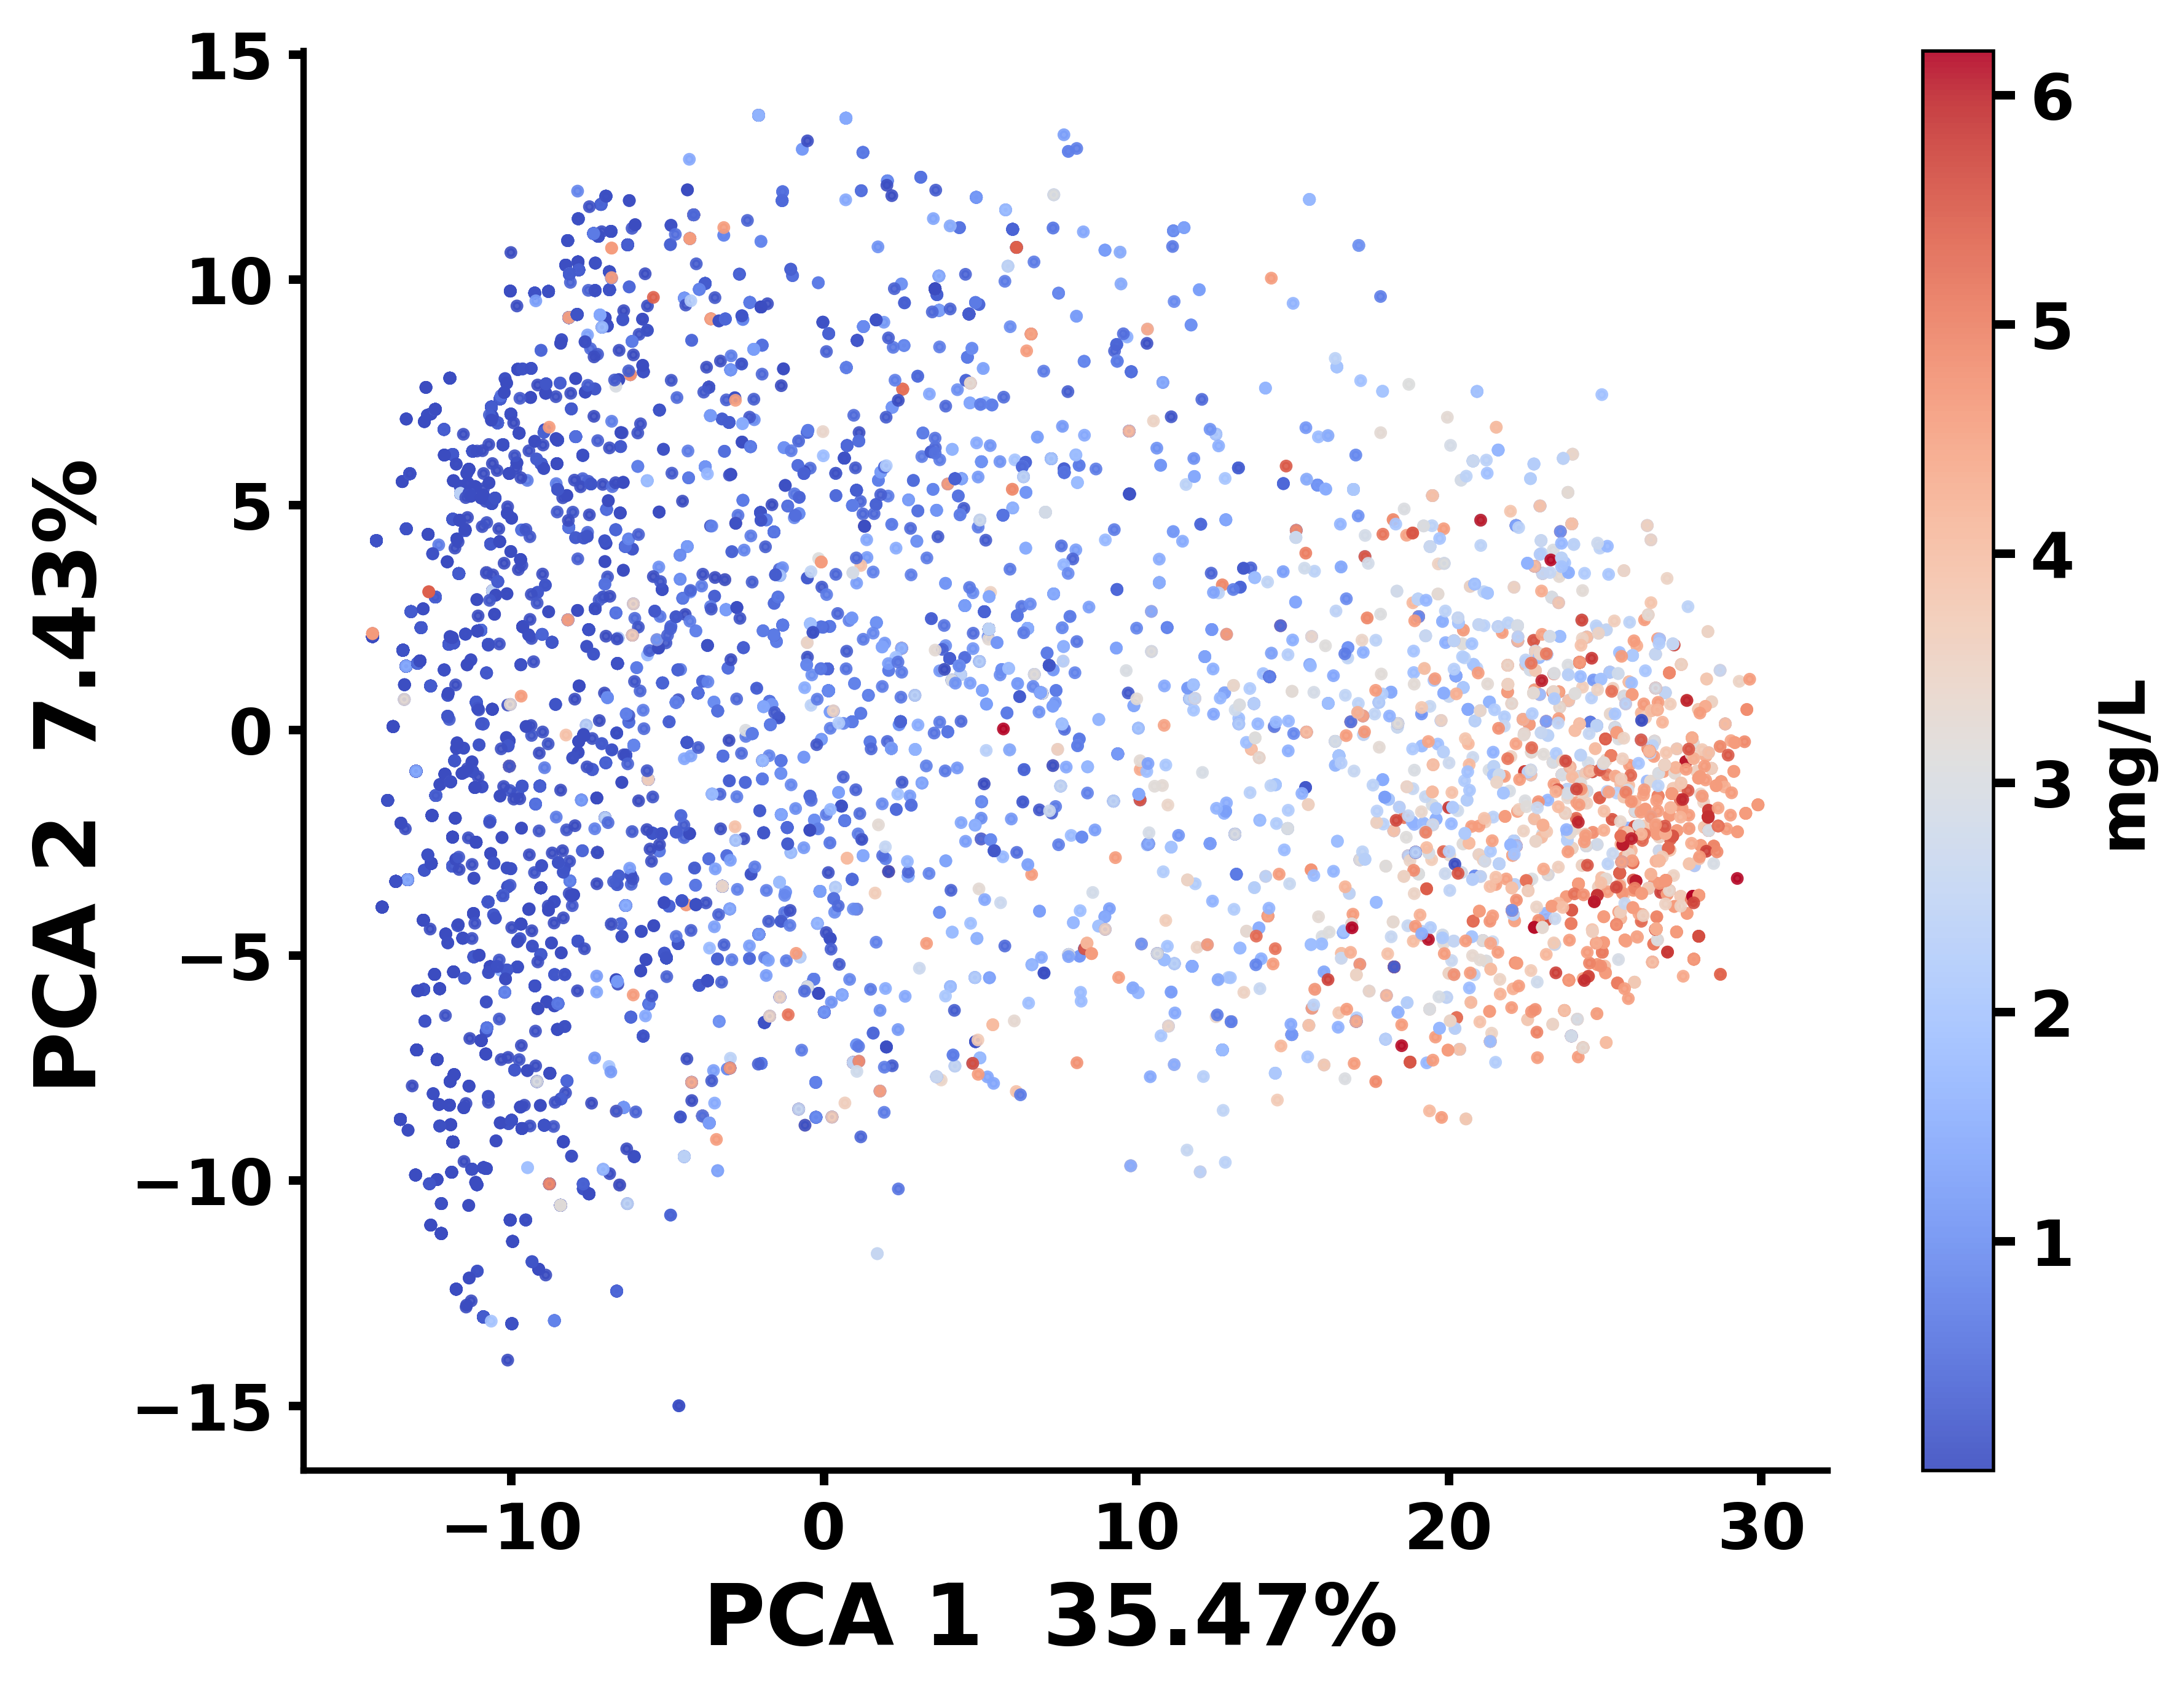

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA



# 使用 PCA 对嵌入进行降维，同时获取主成分的解释方差百分比
def apply_pca(embeddings, n_components=2):
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(embeddings)
    explained_variance = pca.explained_variance_ratio_  # 获取每个主成分的解释方差
    return pca_result, explained_variance


    
# 可视化函数，同时显示解释方差百分比，并加粗字体
def plot_pca_with_variance(pca_result, labels, explained_variance):
    plt.figure(figsize=(8, 6), dpi=500)
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='coolwarm', alpha=0.9,s=4)
    # 添加 colorbar，不指定 fontsize 参数
    cbar = plt.colorbar(scatter)
    cbar.set_label('mg/L', fontsize=15,fontweight='bold')  # 在此处设置字体大小
    #cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.set_tick_params(labelsize=15, width=2, length=5)
    for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold')  # 让刻度标签加粗
    
    plt.xlabel(f'PCA 1  {explained_variance[0]*100:.2f}% ', fontsize=20, fontweight='bold')
    plt.ylabel(f'PCA 2  {explained_variance[1]*100:.2f}% ', fontsize=20, fontweight='bold')

     # 获取当前坐标轴对象
    ax = plt.gca()

    ax.spines['top'].set_visible(False)  # 隐藏左侧框线
    ax.spines['right'].set_visible(False)  # 隐藏底部框线
    ax.spines['top'].set_color('black')   
    ax.spines['right'].set_color('black') 
    ax.spines['top'].set_linewidth(1.5)   
    ax.spines['right'].set_linewidth(1.5) 

    # 让其余边框可见（通常默认已可见）
    ax.spines['bottom'].set_visible(True)  
    ax.spines['left'].set_visible(True)  
    ax.spines['bottom'].set_color('black')  
    ax.spines['left'].set_color('black')  
    ax.spines['bottom'].set_linewidth(1.5)  
    ax.spines['left'].set_linewidth(1.5)  
    

    # 加粗 x 轴和 y 轴的刻度
    ax.tick_params(axis='both', labelsize=15, width=2)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')  # 加粗刻度标签
    
    plt.show()
    



# 使用 PCA 降维，并获取解释方差
pca_result, explained_variance = apply_pca(smiles_embeddings, n_components=2)

# 绘制 PCA 图，并显示每个主成分的解释方差百分比
plot_pca_with_variance(pca_result, mgperL, explained_variance)

In [45]:
data_train = pd.read_excel('./algae_EC10_train.xlsx')

In [46]:
Duration_Value= data_train['Duration_Value'].values
smiles_data = data_train['SMILES_Canonical_RDKit'].tolist()
mgperL = data_train['mgperL'].values

mgperL=np.log1p(mgperL)

In [47]:
# 提取 SMILES 的嵌入表示
def extract_embeddings(smiles_list, model, tokenizer, device):
    embeddings = []
    model.eval()  # 设置模型为评估模式
    with torch.no_grad():
        for smiles in smiles_list:
            # Tokenize the SMILES string
            tokens = tokenizer(smiles, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
            
            # 通过 ChemBERTa 模型获得输出
            outputs = model.chemberta(**tokens)  # 提取 ChemBERTa 模型的输出
            
            # 提取 [CLS] token 的嵌入作为 SMILES 的整体嵌入
            cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()  # 获取多维的 [CLS] 嵌入
            embeddings.append(cls_embedding)
    
    return np.vstack(embeddings)  # 将所有嵌入拼接成一个矩阵

# 提取嵌入
smiles_embeddings = extract_embeddings(smiles_data, model, tokenizer, device)

In [48]:
# 将需要的列拼接成输入 X
x_train = np.hstack((smiles_embeddings, data_train['Duration_Value'].values.reshape(-1, 1)))


In [49]:
y_train = mgperL

In [ ]:
# # 将需要的列拼接成输入 X
# X = np.hstack((smiles_embeddings, data['Duration_Value'].values.reshape(-1, 1)))

# # 拼接编码后的列（如果存在）
# for encoded_feature in [effect_encoded, endpoint_encoded, species_encoded]:
#     if encoded_feature is not None:
#         X = np.hstack((X, encoded_feature))

# # 目标值 y
# y = mgperL

In [30]:
#np.save('./train_smiles/algae_EC10_train_smiles_embeddings.npy', smiles_embeddings)

In [50]:
testdata = pd.read_excel('./algae_EC10_test.xlsx')

In [51]:
testdata

,Duration_Value,effect,endpoint,species_group,CAS,SMILES_Canonical_RDKit,mgperL,std_SMILES
0,24,POP,EC10,algae,1014-70-6,CCNc1nc(NCC)nc(SC)n1,0.0009,CCNc1nc(NCC)nc(SC)n1
1,24,POP,EC10,algae,103-90-2,CC(=O)Nc1ccc(O)cc1,0.1660,CC(=O)Nc1ccc(O)cc1
2,24,POP,EC10,algae,107-13-1,C=CC#N,0.4100,C=CC#N
3,24,POP,EC10,algae,108-95-2,Oc1ccccc1,4.9525,Oc1ccccc1
4,24,POP,EC10,algae,111-17-1,O=C(O)CCSCCC(=O)O,43.5000,O=C(O)CCSCCC(=O)O
...,...,...,...,...,...,...,...,...
275,96,POP,EC10,algae,90-02-8,O=Cc1ccccc1O,4.4000,O=Cc1ccccc1O
276,96,POP,EC10,algae,90-13-1,Clc1cccc2ccccc12,0.1000,Clc1cccc2ccccc12
277,96,POP,EC10,algae,95-76-1,Nc1ccc(Cl)c(Cl)c1,0.2600,Nc1ccc(Cl)c(Cl)c1
278,96,POP,EC10,algae,96-09-3,c1ccc(C2CO2)cc1,12.0000,c1ccc(C2CO2)cc1


In [52]:

smiles_testdata = testdata['SMILES_Canonical_RDKit'].tolist()
y_test = testdata['mgperL'].values

y_test=np.log1p(y_test)

# 提取嵌入
smiles_embeddings_test = extract_embeddings(smiles_testdata, model, tokenizer, device)
# 将需要的列拼接成输入 X
x_test = np.hstack((smiles_embeddings_test, testdata['Duration_Value'].values.reshape(-1, 1)))



In [53]:
x_test.shape

(280, 769)

In [54]:
x_train.shape

(2980, 769)

In [28]:
# from rdkit import Chem

# def standardize_smiles(smiles: str) -> str:
#     """
#     使用 RDKit 将 SMILES 转化为规范（canonical）形式。
#     如有需要，可在此处添加更多的标准化逻辑，比如去除盐、质子化等。
#     """
#     try:
#         mol = Chem.MolFromSmiles(smiles)
#         if mol is not None:
#             return Chem.MolToSmiles(mol, canonical=True)
#         else:
#             return None
#     except:
#         return None


# test_smiles = testdata['SMILES'].apply(standardize_smiles)

In [29]:
# y_test = testdata['Experimental'].values
# x_test = extract_embeddings(test_smiles, model, tokenizer, device)

In [ ]:
import numpy as np
from sklearn.model_selection import ParameterSampler
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm


import optuna

def perform_optuna_search_regression(model, x_train, y_train, x_test, y_test, n_trials=40):
    # 转换为 NumPy 数组
    x_train = np.array(x_train)
    y_train = np.array(y_train)
    x_test = np.array(x_test)
    y_test = np.array(y_test)

    def objective(trial):
        # 从给定的参数集合中选择超参数
        n_estimators = trial.suggest_categorical("n_estimators", [100, 300, 500, 700, 1000])
        learning_rate = trial.suggest_categorical("learning_rate", [0.01, 0.05, 0.1, 0.2])
        max_depth = trial.suggest_categorical("max_depth", [3, 5, 7, 9])
        subsample = trial.suggest_categorical("subsample", [0.7, 0.8, 1.0])
        colsample_bytree = trial.suggest_categorical("colsample_bytree", [0.6, 0.8, 1.0])

        # 复制模型并设置超参数
        temp_model = clone(model)
        temp_model.set_params(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=colsample_bytree
        )

        # 标准化数据：仅用训练集拟合，再对测试集转换
        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        # 训练模型并预测
        temp_model.fit(x_train_scaled, y_train)
        y_pred = temp_model.predict(x_test_scaled)

        # 计算误差：error = max(y_true, y_pred) / min(y_true, y_pred)
        errors = np.maximum(y_test, y_pred) / np.minimum(y_test, y_pred)
        median_error = np.median(errors)
        print("当前的中值误差：",median_error)
        return median_error

    # 创建 Optuna study，目标为最小化中值误差
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    best_median_error = study.best_value

    # 使用最佳参数训练最终模型并预测
    best_model = clone(model)
    best_model.set_params(**best_params)
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    best_model.fit(x_train_scaled, y_train)
    y_pred = best_model.predict(x_test_scaled)

    return best_params, y_pred, best_median_error

# 示例：定义 XGBoost 模型和参数网格（此处参数由 Optuna 的 categorical 选项给定）
from xgboost import XGBRegressor
xgb = XGBRegressor(verbose=0, n_jobs=-1)

# 假设 x_train, y_train, x_test, y_test 已经定义好
print("Training XGBoost with Optuna hyperparameter search...")
best_params_xgb, y_pred, best_median_error = perform_optuna_search_regression(
    xgb, x_train, y_train, x_test, y_test, n_trials=40
)

print("Best Parameters for XGBoost:", best_params_xgb)
print("Best Median Error:", best_median_error)

In [56]:
error  = np.maximum(y_test, y_pred) / np.minimum(y_test, y_pred)

In [57]:
# 计算中值误差
median_error = np.median(error)

# 打印结果
print("中值误差:", median_error)
print("绝对误差示例:", np.mean(error))

中值误差: 1.7760865399462542
绝对误差示例: 77.31447485185468


In [58]:
# 计算异常值的分位数
lower_bound = np.percentile(error, 5)
upper_bound = np.percentile(error, 95)

# 截断异常值
error_1 = np.clip(error, lower_bound, upper_bound)

In [59]:
np.mean(error_1)

np.float64(6.549714548531101)

In [60]:
median_error = np.median(error_1)

In [61]:
median_error

np.float64(1.7760865399462542)

In [62]:
total = len(error)
pct_gt_1000 = (error > 1000).sum() / total * 100
pct_gt_100 = (error > 100).sum() / total * 100
pct_gt_10 = (error > 10).sum() / total * 100

print(f"大于 1000 的百分比: {pct_gt_1000:.2f}%")
print(f"大于 100 的百分比: {pct_gt_100:.2f}%")
print(f"大于 10 的百分比: {pct_gt_10:.2f}%")

大于 1000 的百分比: 0.36%
大于 100 的百分比: 4.29%
大于 10 的百分比: 14.29%
